In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
print(f"train shape: {train.shape}")
print(f"test shape:  {test.shape}")
train.head()

train shape: (1460, 81)
test shape:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Target variable: SalePrice
Real sale prices for 1460 houses sold in Ames, Iowa between 2006-2010.

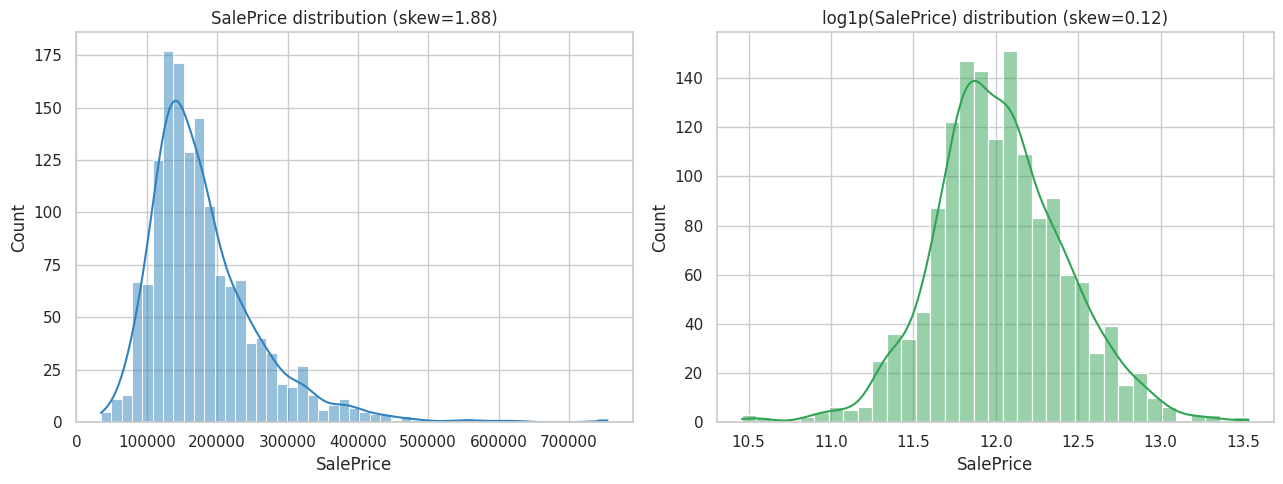

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="#3182bd")
axes[0].set_title(f"SalePrice distribution (skew={train['SalePrice'].skew():.2f})")
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="#31a354")
axes[1].set_title(f"log1p(SalePrice) distribution (skew={np.log1p(train['SalePrice']).skew():.2f})")
plt.tight_layout()
plt.savefig("../outputs/eda_saleprice_distribution.png", dpi=140)
plt.show()
print(train["SalePrice"].describe())

SalePrice is strongly right-skewed (a small number of very expensive homes
pull the mean above the median). log1p-transforming it makes the
distribution close to normal, which is why we predict log(SalePrice)
throughout this project, then invert at the end.

## 2. Missing values
Per `data_description.txt`, many NaNs encode "this feature doesn't exist
on the house" rather than "value unknown" -- e.g. NaN in PoolQC just means
the house has no pool.

              n_missing  pct_missing
PoolQC             1453         99.5
MiscFeature        1406         96.3
Alley              1369         93.8
Fence              1179         80.8
MasVnrType          872         59.7
FireplaceQu         690         47.3
LotFrontage         259         17.7
GarageType           81          5.5
GarageYrBlt          81          5.5
GarageFinish         81          5.5
GarageQual           81          5.5
GarageCond           81          5.5
BsmtExposure         38          2.6
BsmtFinType2         38          2.6
BsmtQual             37          2.5
BsmtCond             37          2.5
BsmtFinType1         37          2.5
MasVnrArea            8          0.5
Electrical            1          0.1


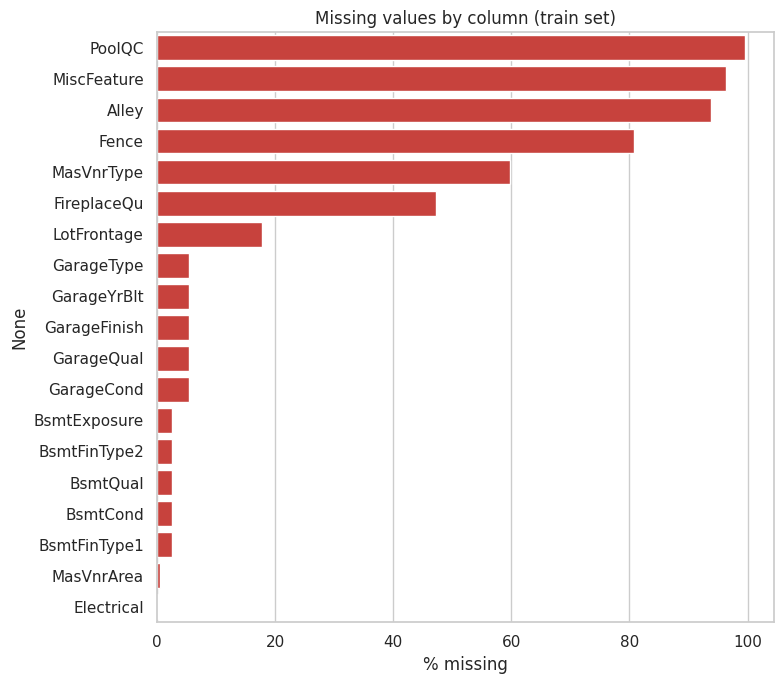

In [3]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)
missing_df = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
print(missing_df)

plt.figure(figsize=(8, 7))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="#de2d26")
plt.xlabel("% missing")
plt.title("Missing values by column (train set)")
plt.tight_layout()
plt.savefig("../outputs/eda_missing_values.png", dpi=140)
plt.show()

## 3. Correlation with SalePrice (numeric features)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


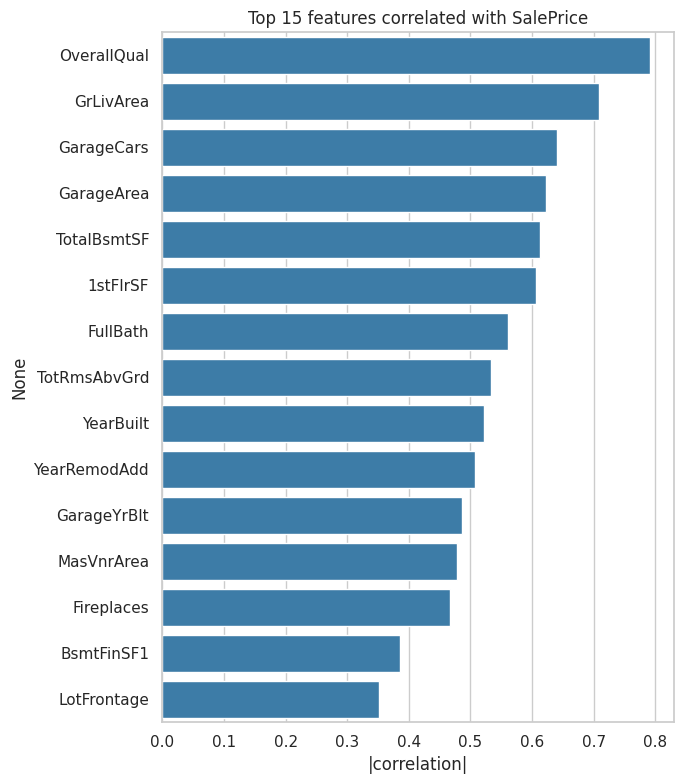

In [4]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()["SalePrice"].sort_values(ascending=False)
print(corr.head(16))

plt.figure(figsize=(7, 8))
top_corr = corr.drop("SalePrice").abs().sort_values(ascending=False).head(15)
sns.barplot(x=top_corr.values, y=top_corr.index, color="#2c7fb8")
plt.title("Top 15 features correlated with SalePrice")
plt.xlabel("|correlation|")
plt.tight_layout()
plt.savefig("../outputs/eda_top_correlations.png", dpi=140)
plt.show()

`OverallQual` (overall material/finish rating) and `GrLivArea` (above-grade
living area) are by far the strongest single predictors -- this is exactly
why we engineer interaction terms like `QualGrLivArea` and `OverallQual_sq`
in the feature engineering step.

## 4. Key relationships

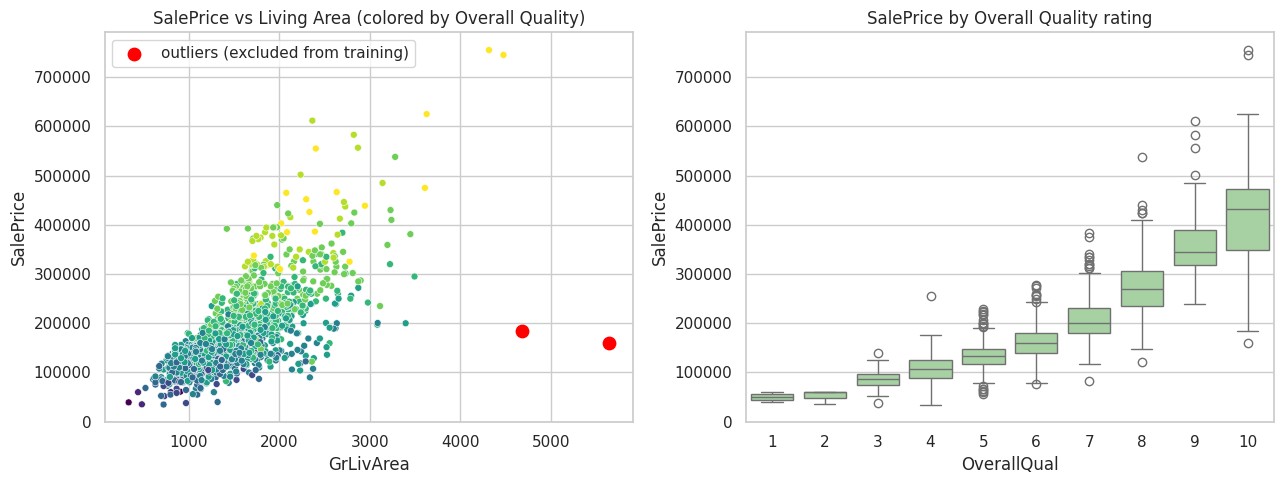


Found 2 GrLivArea>4000-but-cheap outliers; these are dropped during feature engineering (documented data quirk in this dataset).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", hue="OverallQual",
                 palette="viridis", ax=axes[0], s=25, legend=False)
axes[0].set_title("SalePrice vs Living Area (colored by Overall Quality)")
# highlight the two well-known outliers (huge house, suspiciously low price)
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
axes[0].scatter(outliers["GrLivArea"], outliers["SalePrice"], color="red", s=80,
                 label="outliers (excluded from training)")
axes[0].legend()

sns.boxplot(data=train, x="OverallQual", y="SalePrice", ax=axes[1], color="#a1d99b")
axes[1].set_title("SalePrice by Overall Quality rating")
plt.tight_layout()
plt.savefig("../outputs/eda_key_relationships.png", dpi=140)
plt.show()

print(f"\nFound {len(outliers)} GrLivArea>4000-but-cheap outliers; these are "
      "dropped during feature engineering (documented data quirk in this dataset).")

## 5. Neighborhood effect on price

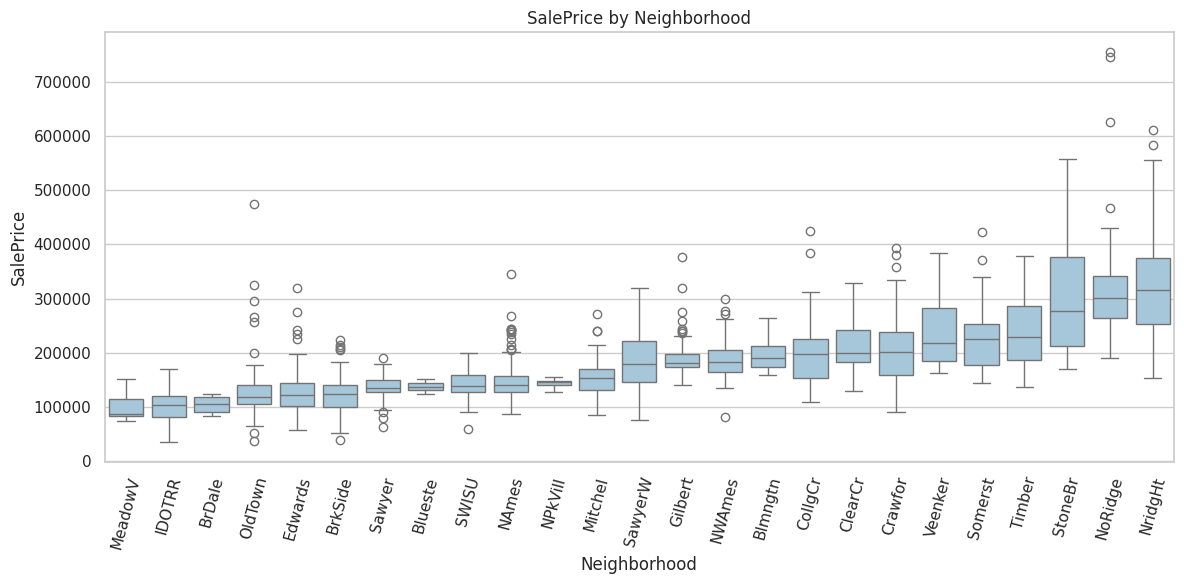

In [6]:
plt.figure(figsize=(12, 6))
order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order, color="#9ecae1")
plt.xticks(rotation=75)
plt.title("SalePrice by Neighborhood")
plt.tight_layout()
plt.savefig("../outputs/eda_neighborhood_price.png", dpi=140)
plt.show()

Location matters enormously -- median prices vary by roughly 4x between the
cheapest (MeadowV) and most expensive (NoRidge/NridgHt/StoneBr) neighborhoods.
This is why `Neighborhood` is one-hot encoded rather than dropped or
arbitrarily ordinal-encoded.

## Summary of EDA -> feature engineering decisions

1. **Target transform**: predict `log1p(SalePrice)` due to right skew.
2. **Missing values**: encode "no feature" NaNs as None/0 rather than
   imputing; use neighborhood-median for `LotFrontage`.
3. **Outliers**: drop the 2 houses with `GrLivArea > 4000` and
   `SalePrice < 300000` -- well documented data quirks, not real signal.
4. **Strongest predictors**: `OverallQual`, `GrLivArea`, `TotalSF` (engineered),
   `Neighborhood`, garage/basement size -- all get extra engineered features
   or interaction terms.
5. **Categorical encoding**: ordinal encode quality-scale columns
   (Ex/Gd/TA/Fa/Po), one-hot encode nominal columns (Neighborhood, etc).